# Multiple Linear Regression

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

The last notebook had **one** input:

```text
Income = m * Age + c
```

Real life is rarely one column. Income depends on age **and** education. So we give the
model both columns:

```text
Income = b0 + w1 * Age + w2 * Degrees
```

That is multiple linear regression. Same class, `LinearRegression`. Same three verbs.
Only `X` gets wider.

| | Simple | Multiple |
|---|---|---|
| input columns | 1 | 2 or more |
| formula | `y = m*x + c` | `y = b0 + w1*x1 + w2*x2 + ...` |
| `coef_` | one number | **one number per column** |
| `intercept_` | one number | still one number |
| picture | a line | a **flat sheet** (a plane) |

**"Linear" does not mean one line.** It means every input keeps its own *fixed* rate.
Age always costs the same per year, whatever the number of degrees. Nothing bends,
nothing multiplies. That is what makes the model easy to read — and what makes it fail
when reality bends.

In [1]:
import pandas as pd

## 1. The data

Three columns, six rows.

| column | role | name in code |
|---|---|---|
| `Age` | input (feature) | `x` |
| `Degrees` | input (feature) | `x` |
| `Income` | the answer we want (target) | `y` |

Six rows is a **toy** dataset. It is the right size for learning the mechanics and the
wrong size for trusting any number that comes out. That warning comes back at `score()`.

> The path here is absolute, so this cell only runs on this machine. A repo-relative
> path — `../02_pandas/DataSet/age2.csv` — travels better.

In [2]:
df  = pd.read_csv("/Users/kaliprasad/Documents/MACHINE_LEARNING/AI_ML_Series/02_data_toolkit_apps/02_pandas/DataSet/age2.csv")
df.head(5)

,Age,Degrees,Income
0,50,5,5000
1,60,3,4500
2,10,1,7000
3,20,2,6000
4,40,7,3500


## 2. Look at one input at a time

Before fitting anything, plot each input against the target. Two inputs, two charts.

Both charts slope **downward**: older people in this table earn less, and more degrees
also means less income. That is odd for real life, and a good reminder that six invented
rows are not the world.

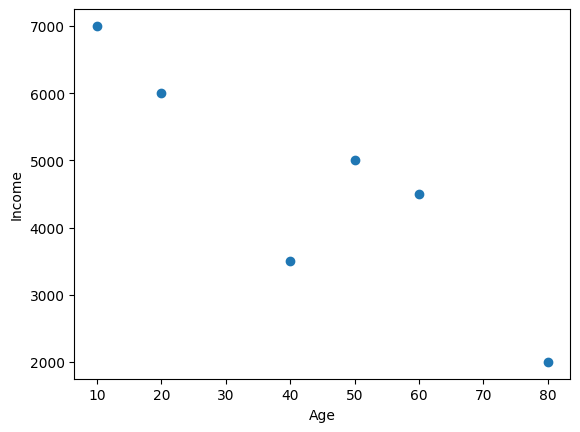

In [3]:
import matplotlib.pyplot as plt
plt.scatter(df['Age'],df['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.show()

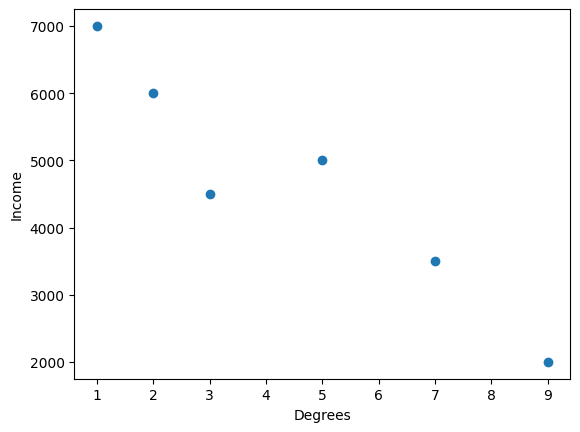

In [4]:
plt.scatter(df['Degrees'],df['Income'])
plt.xlabel('Degrees')
plt.ylabel('Income')
plt.show()

## 3. Two charts are not two models

Here is the trap. It feels like you could fit a line on each chart and add them up.
You cannot, and this is the whole idea of multiple regression.

`Age` and `Degrees` are **not independent** in this table — they move together
(correlation `0.78`). So part of what "age" seems to explain is really education
sneaking in through the back door.

Fit the columns separately and together, and the same column gets a different number:

| model | what `Age` is worth |
|---|---|
| `Age` alone | **−61** income per year |
| `Age` **and** `Degrees` together | **−20.4** income per year |

Same data, same column. The coefficient dropped by two thirds because `Degrees` took
back the credit it was owed.

```text
   Age alone           →  "everything that comes with getting older"
   Age beside Degrees  →  "age only, education already accounted for"
```

That second reading is the useful one, and it exists only when the columns are fitted
**together**. This is why we pass a table to `fit`, not one column at a time.

## 4. `X` becomes a table with two columns

```python
x = df[['Age', 'Degrees']]   # double brackets -> DataFrame, 2 columns
y = df['Income']             # single brackets -> Series, 1 column
```

| | brackets | type | shape |
|---|---|---|---|
| `x` | `[['Age','Degrees']]` | DataFrame | `(6, 2)` |
| `y` | `['Income']` | Series | `(6,)` |

sklearn always wants `X` **2-D** and `y` **1-D**. In the last notebook the double
brackets looked like a nuisance; here they are simply how you ask for two columns.

**The column order you type is the order `coef_` comes back in.** Remember that — it is
the only link between a number and the column it belongs to.

In [5]:
x = df[['Age', 'Degrees']]
y = df['Income']

## 5. Split before fitting

`test_size=0.3` on 6 rows: **4 rows to learn from, 2 rows kept hidden**.

`random_state=0` fixes which rows go where, so this notebook gives the same numbers
every run.

Be honest about the size: 4 rows to find 3 numbers (`b0`, `w1`, `w2`) is almost no
information. The workflow is correct; the confidence in the result should stay low.

In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=0)
X_train

,Age,Degrees
1,60,3
3,20,2
0,50,5
4,40,7


In [7]:
X_test

,Age,Degrees
5,80,9
2,10,1


## 6. `fit()` — find the flat sheet closest to the dots

With one input, `fit` looked for the best **line**. With two inputs, it looks for the
best **plane** — a flat sheet floating over the Age–Degrees floor.

"Best" means the same thing as before: the total of the squared vertical gaps between
the real dots and the sheet is as small as possible. This is **least squares**.

```mermaid
flowchart LR
    A["X_train (4 rows x 2 cols)<br/>y_train (4 values)"] --> B["fit()"]
    B --> C["intercept_ = 7111.11<br/>coef_ = [-20.37, -351.85]"]
    E["a new row<br/>Age=80, Degrees=9"] --> D["predict()"]
    C --> D
    D --> F["7111.11 - 20.37*80 - 351.85*9<br/>= 2314.81"]
    style C fill:#2f6fed,color:#fff
    style F fill:#2f9e6f,color:#fff
```

Four rows went in. **Three numbers** came out, and the rows are not kept. That is the
whole model — you could email it.

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor
> curriculum.* There is no loop and no learning rate here. `LinearRegression` solves the
> least-squares system directly with linear algebra (`scipy.linalg.lstsq`). Gradient
> descent belongs to models that have no closed-form answer.

In [8]:
from sklearn.linear_model import LinearRegression
clf = LinearRegression()

In [9]:
clf.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -20.37,-351.85]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Age','Degrees']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7111
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


## 7. `predict()` — put the row into the formula

No learning happens here. Each test row is multiplied out and added up:

```text
Age=80, Degrees=9 → 7111.11 - 20.37*80 - 351.85*9 = 2314.81   (real answer: 2000)
Age=10, Degrees=1 → 7111.11 - 20.37*10 - 351.85*1 = 6555.56   (real answer: 7000)
```

Those two numbers are exactly what the cell prints. One multiply per column, then one
add. Nothing else is inside `predict`.

In [10]:
clf.predict(X_test)

array([2314.81481481, 6555.55555556])

## 8. `score()` — R², and why 0.976 means little here

`score` returns **R²**: how much of the movement in `y` the model explains.
`1.0` is perfect, `0.0` is no better than always guessing the average.

We got **0.976** on the test rows — and this is where a beginner celebrates and a
reviewer squints:

| | rows | R² |
|---|---|---|
| train | 4 | **0.795** |
| test | 2 | **0.976** |

The test score is *higher* than the train score. That is not skill, it is luck. With two
test points, R² is decided by two numbers, and it swings wildly with a different
`random_state`.

**Takeaway:** a score computed on 2 rows is a number, not evidence. Real evaluation
needs enough test rows, or `cross_val_score`.

In [11]:
clf.score(X_test,y_test)

0.9762688614540466

## 9. `coef_` — one number per column

```text
array([ -20.37037037, -351.85185185 ])
             │              │
             │              └── Degrees   (column 2)
             └── Age                      (column 1)
```

The array follows the order you built `x` in. Two columns, two coefficients. Twenty
columns would give twenty.

**How to read one coefficient:** *if this input goes up by 1 and everything else stays
exactly the same, `y` moves by this much.*

- `Age = -20.37` → one more year, **holding degrees fixed**, and income drops by ~20.
- `Degrees = -351.85` → one more degree, **holding age fixed**, and income drops by ~352.

That phrase "holding the other fixed" is the whole difference from the simple model, and
section 12 draws it.

⚠️ **Do not rank importance by size.** `351` is not "17 times more important" than `20`.
The units are different — one is *per year*, the other is *per degree*. To compare
columns fairly, scale them first (`StandardScaler`), then compare.

In [12]:
clf.coef_

array([ -20.37037037, -351.85185185])

## 10. `intercept_` — the anchor

`7111.11` is the income the formula predicts when **every input is 0**: a person aged 0
with 0 degrees.

Nobody in the table is 0 years old. So the intercept is not a prediction about a real
person — it is the height at which the plane is pinned so that it sits correctly over
the rows we actually have.

| | Simple regression | Multiple regression |
|---|---|---|
| `coef_` | tilts the line | tilts the plane, **once per column** |
| `intercept_` | slides the line up/down | slides the plane up/down |

In [13]:
clf.intercept_

np.float64(7111.11111111111)

## 11. Proof — rebuild `predict()` by hand

If the model really is `b0 + w1*Age + w2*Degrees`, then writing that out ourselves must
give exactly the same numbers. `x.values @ coef_` is the dot product: multiply each
column by its coefficient and add the results.

In [14]:
import numpy as np

b0 = clf.intercept_          # 7111.11
w  = clf.coef_               # [-20.37, -351.85]

by_hand    = b0 + X_test.values @ w      # @ = dot product = w1*Age + w2*Degrees
by_sklearn = clf.predict(X_test)

print("by hand   :", by_hand)
print("by sklearn:", by_sklearn)
print("same? ->", np.allclose(by_hand, by_sklearn))

# spell out one row completely
age, deg = X_test.iloc[0]
print(f"\nrow 0: {b0:.2f} + ({w[0]:.2f} * {age}) + ({w[1]:.2f} * {deg}) = {b0 + w[0]*age + w[1]*deg:.2f}")

by hand   : [2314.81481481 6555.55555556]
by sklearn: [2314.81481481 6555.55555556]
same? -> True

row 0: 7111.11 + (-20.37 * 80) + (-351.85 * 9) = 2314.81


## 12. The visual — one line becomes a plane

This is the picture worth keeping. Two inputs make a floor (Age × Degrees), and the
model is a **flat sheet** hovering above that floor. The red sticks are the errors: the
vertical distance from each real person to the sheet. `fit()` chose the sheet that makes
the total of those squared sticks as small as possible.

```text
   1 input  →  a LINE      in 2-D   (x, y)
   2 inputs →  a PLANE     in 3-D   (x1, x2, y)
   n inputs →  a HYPERPLANE in n+1-D  — same maths, no picture
```

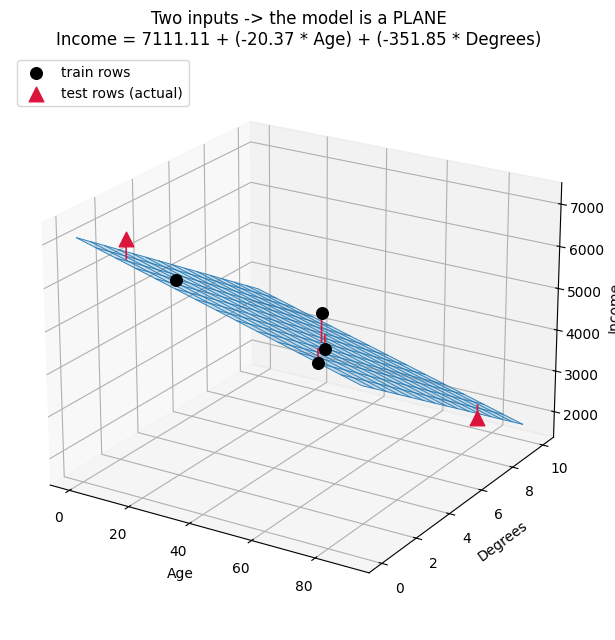

In [15]:
import numpy as np
import matplotlib.pyplot as plt

b0 = clf.intercept_
w1, w2 = clf.coef_

fig = plt.figure(figsize=(9, 6.5))
ax = fig.add_subplot(111, projection='3d', computed_zorder=False)

# the fitted plane: Income = b0 + w1*Age + w2*Degrees
ages    = np.linspace(0, 90, 15)
degrees = np.linspace(0, 10, 15)
AG, DG = np.meshgrid(ages, degrees)
INCOME = b0 + w1 * AG + w2 * DG

ax.plot_wireframe(AG, DG, INCOME, color="tab:blue", lw=0.7, alpha=0.9)
ax.plot_surface(AG, DG, INCOME, color="tab:blue", alpha=0.20, shade=False)

# red stick = the error for that person
for age, deg, real in zip(df['Age'], df['Degrees'], y):
    ax.plot([age, age], [deg, deg], [real, b0 + w1*age + w2*deg],
            color="crimson", lw=1.2, zorder=10)

ax.scatter(X_train['Age'], X_train['Degrees'], y_train, s=70, color="black",
           depthshade=False, label="train rows", zorder=11)
ax.scatter(X_test['Age'], X_test['Degrees'], y_test, s=110, color="crimson",
           marker="^", depthshade=False, label="test rows (actual)", zorder=11)

ax.set_xlabel("Age"); ax.set_ylabel("Degrees"); ax.set_zlabel("Income")
ax.set_title(f"Two inputs -> the model is a PLANE\nIncome = {b0:.2f} + ({w1:.2f} * Age) + ({w2:.2f} * Degrees)")
ax.legend(loc="upper left")
ax.view_init(22, -58)
plt.tight_layout(); plt.show()

## 13. What "holding the other column fixed" actually looks like

Slice the plane at a fixed number of degrees and you get a **line**. Slice it at a
different number of degrees and you get another line — same tilt, different height.

- **Left chart:** three slices. All parallel. Their shared tilt *is* `coef_[0] = -20.37`.
  Changing `Degrees` only moves the line up or down, never bends it. That is what
  "linear" buys you.
- **Right chart:** the same `Age` column fitted alone (red) versus inside the two-column
  model (blue). The red line is much steeper, because when `Degrees` is missing, `Age`
  is forced to carry its effect too.

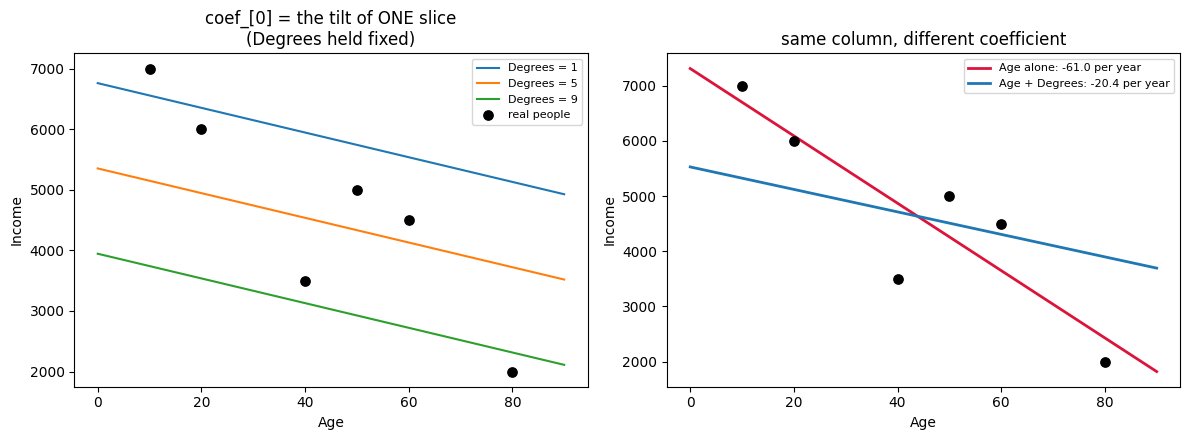

In [16]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

b0 = clf.intercept_
w1, w2 = clf.coef_
ages = np.linspace(0, 90, 50)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# --- left: slice the plane at fixed Degrees -> parallel lines
for d in [1, 5, 9]:
    ax[0].plot(ages, b0 + w1*ages + w2*d, label=f"Degrees = {d}")
ax[0].scatter(df['Age'], y, color="black", s=45, zorder=5, label="real people")
ax[0].set_title("coef_[0] = the tilt of ONE slice\n(Degrees held fixed)")

# --- right: Age alone vs Age inside the multiple model
simple = LinearRegression().fit(df[['Age']], y)
ax[1].scatter(df['Age'], y, color="black", s=45, zorder=5)
ax[1].plot(ages, simple.intercept_ + simple.coef_[0]*ages, color="crimson", lw=2,
           label=f"Age alone: {simple.coef_[0]:.1f} per year")
ax[1].plot(ages, b0 + w1*ages + w2*df['Degrees'].mean(), color="tab:blue", lw=2,
           label=f"Age + Degrees: {w1:.1f} per year")
ax[1].set_title("same column, different coefficient")

for a in ax:
    a.set_xlabel("Age"); a.set_ylabel("Income"); a.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 14. Predict every row

The same formula applied to all six rows, so predictions can be drawn next to the real
values. (Rows 0–3 were used for training, so this is not a fair test — it is only for
the picture.)

In [17]:
y_pred = clf.predict(x)
y_pred

array([4333.33333333, 4833.33333333, 6555.55555556, 6000.        ,
       3833.33333333, 2314.81481481])

## 15. `sns.regplot(x=y, y=y_pred)` — actual against predicted

This chart does **not** show the model's plane. It puts the real income on the x-axis
and the predicted income on the y-axis, one dot per person.

A perfect model would put every dot on the 45° diagonal, because predicted would equal
actual. `regplot` then fits its **own** fresh straight line through those dots and
shades a confidence band around it.

Read it as a **report card**, not as the model: the closer the dots hug the diagonal,
the better. (Both axes get labelled `Income`, which is confusing — the next cell fixes
that.)

<Axes: xlabel='Income'>

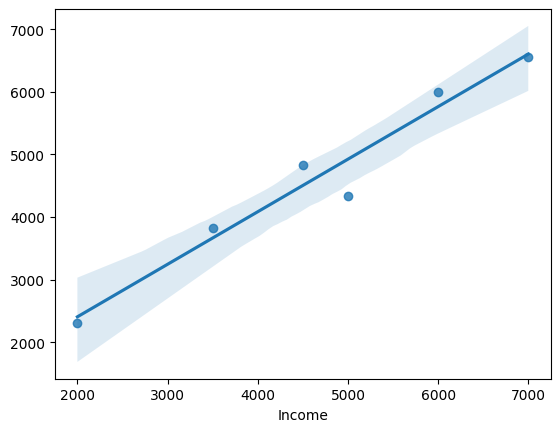

In [18]:
import seaborn as sns
sns.regplot(x=y, y=y_pred)

## 16. The same check, drawn honestly

`regplot` draws the *best line through the dots*. What we actually want to compare
against is the **45° line where predicted = actual**. Those are different lines, and the
gap between a dot and the diagonal is the real error.

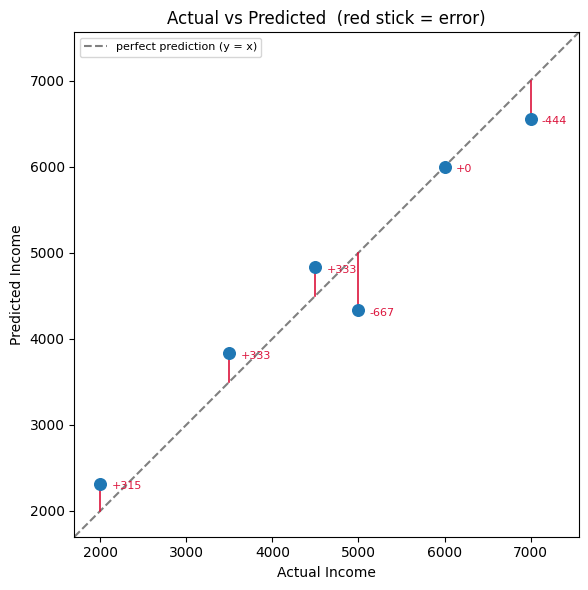

In [19]:
import matplotlib.pyplot as plt

y_pred = clf.predict(x)

fig, ax = plt.subplots(figsize=(6.5, 6))
lim = [y.min() * 0.85, y.max() * 1.08]

ax.plot(lim, lim, ls="--", color="grey", label="perfect prediction (y = x)")
ax.scatter(y, y_pred, s=70, color="tab:blue", zorder=5)
for actual, pred in zip(y, y_pred):
    ax.plot([actual, actual], [actual, pred], color="crimson", lw=1.2)   # the error

for actual, pred in zip(y, y_pred):
    ax.annotate(f"{pred - actual:+.0f}", (actual, pred), textcoords="offset points",
                xytext=(8, -4), fontsize=8, color="crimson")

ax.set_xlabel("Actual Income"); ax.set_ylabel("Predicted Income")
ax.set_title("Actual vs Predicted  (red stick = error)")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 17. Wrap up

### The whole model in one line

```text
Income = 7111.11 + (-20.37 * Age) + (-351.85 * Degrees)
          │            │                │
      intercept_    coef_[0]         coef_[1]
```

### Common mistakes

| Mistake | What actually happens |
|---|---|
| Reading `coef_` in the wrong order | The array follows **your** column order in `x`. Reorder the columns and the numbers move with them. Print `dict(zip(x.columns, clf.coef_))` instead of trusting memory. |
| "The biggest coefficient is the most important column" | Only true if every column shares the same unit and scale. Years and degrees do not. Scale first, then compare. |
| Passing a single column as `df['Age']` | `LinearRegression` needs `X` 2-D. One column must still be `df[['Age']]`. |
| Trusting a high R² from a tiny test set | Ours is `0.976` from **2 rows**, while training sits at `0.795`. Change `random_state` and it moves a lot. |
| Adding every available column "because more is better" | Correlated columns (here `0.78`) split the credit between themselves, so the individual coefficients get unstable — **multicollinearity**. The predictions can still be fine; the *explanations* are what break. |
| Reading the intercept as a real person | `Age = 0, Degrees = 0` does not exist in this data. It anchors the plane, nothing more. |

### Where this is used

Baseline before anything fancy — price estimates, demand forecasts, delivery-time
prediction, capacity planning. It stays in production because it is fast, and because
each coefficient can be explained to a regulator or a business owner. A gradient-boosted
model may score better and still lose the argument.

> 💡 **Engineering view.** Three floats and a column order — that is the entire
> artefact. It is smaller than a config file, it serves in microseconds, and it needs
> no GPU. The risky part of shipping it is not the model, it is guaranteeing that the
> columns arrive in the **same order** at serving time as at training time. That is a
> data-contract problem, and it is exactly what `Pipeline` exists to lock down.

### Interview view

1. Simple vs multiple regression: one input column vs many; a line vs a plane.
2. A coefficient is a **partial** effect — the effect of that column with the others
   held fixed.
3. `coef_` is an array whose order is the column order of `X`.
4. Coefficient magnitudes are only comparable after scaling.
5. Correlated inputs (multicollinearity) destabilise coefficients but not necessarily
   predictions.

### Key takeaway

**If you remember only one thing:** multiple linear regression is still one straight
formula — `y = b0 + w1*x1 + w2*x2 + ...` — and each coefficient answers *"if only this
column moves by 1, how much does y move?"*. Adding a column can change every other
coefficient, so a coefficient is a statement about **the model it lives in**, never
about the column on its own.